# Lab 03: Pitch Classification

---
author: Isabella Iniguez
date: October 2, 2024
embed-resources: true
---

## Introduction

In this report, we develop a classification model that predicts the pitch type of a pitch thrown by Shohei Ohtani given the pitch’s velocity, rotation, movement, and position of the batter. By building this model, we aim to be able to automatically and reliably display the pitch type for each pitch in real-time to both the stadium and television broadcast.

## Methods

In [127]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# machine learning
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### Data

In [128]:
# load data
pitches_train = pd.read_parquet(
    "https://cs307.org/lab-03/data/pitches-train.parquet"
)
pitches_test = pd.read_parquet(
    "https://cs307.org/lab-03/data/pitches-test.parquet"
)
pitches_train

,pitch_name,release_speed,release_spin_rate,pfx_x,pfx_z,stand
0,Sweeper,84.7,2667.0,1.25,0.01,R
1,Sweeper,83.9,2634.0,1.41,0.20,R
2,Sweeper,84.4,2526.0,1.26,0.25,R
3,Curveball,74.3,2389.0,0.93,-1.10,L
4,Sweeper,85.6,2474.0,1.08,0.52,R
...,...,...,...,...,...,...
2623,Split-Finger,91.8,1314.0,-0.30,0.08,R
2624,Sweeper,86.9,2440.0,1.11,0.51,R
2625,4-Seam Fastball,99.2,2320.0,0.04,0.81,R
2626,4-Seam Fastball,97.9,2164.0,0.08,1.06,R


### Data Dictionary

The `Train` data contains observations each containing information about a single pitch thrown by Shohei Ohtani during the 2022 MLB Season.

The `Test`  data contains observations each containing information about a single pitch thrown by Shohei Ohtani during the first half of the 2023 MLB Season.

The variables considered are:

#### Response

`pitch_name`

-   `[object]` the name of the pitch, which is the name of the pitch type thrown

#### Features

`release_speed`	

-   `[float64]` pitch velocity (miles per hour) measured shortly after leaving the pitcher’s hand

`release_spin_rate`

-   `[float64]` pitch spin rate (revolutions per minute) measured shortly after leaving the pitcher’s hand

`pfx_x`

-   `[float64]` horizontal movement (feet) of the pitch from the catcher’s perspective.

`pfx_z`

-   `[float64]` vertical movement (feet) of the pitch from the catcher’s perspective.

`stand`

-   `[object]` side of the plate batter is standing, either L (left) or R (right)

In [129]:
# summary statistics
# Pitch Type Statistics
c = pitches_train[['pitch_name','release_speed']].groupby('pitch_name').agg('count').rename(columns={'release_speed':'count'})
p = (c / len(pitches_train)).rename(columns={'count':'proportion'})
c.join(p)


,count,proportion
pitch_name,,
4-Seam Fastball,718,0.273212
Curveball,222,0.084475
Cutter,233,0.088661
Sinker,97,0.036910
Slider,63,0.023973
Split-Finger,312,0.118721
Sweeper,983,0.374049


In [130]:
# Velocity by Pitch Type Statistics
m = pitches_train[['pitch_name','release_speed']].groupby('pitch_name').agg('mean').rename(columns={'release_speed':'mean'})
s = pitches_train[['pitch_name','release_speed']].groupby('pitch_name').agg('std').rename(columns={'release_speed':'std'})
m.join(s)

,mean,std
pitch_name,,
4-Seam Fastball,97.270613,1.699270
Curveball,77.679730,3.215206
Cutter,90.742060,2.364489
Sinker,97.160825,1.829592
Slider,85.203175,2.401543
Split-Finger,89.291346,1.759299
Sweeper,85.336419,1.862552


In [131]:
# Spin by Pitch Type Statistics
m = pitches_train[['pitch_name','release_spin_rate']].groupby('pitch_name').agg('mean').rename(columns={'release_spin_rate':'mean'})
s = pitches_train[['pitch_name','release_spin_rate']].groupby('pitch_name').agg('std').rename(columns={'release_spin_rate':'std'})
m.join(s)

,mean,std
pitch_name,,
4-Seam Fastball,2217.331933,114.754683
Curveball,2482.666667,119.854726
Cutter,2378.424893,206.685887
Sinker,1972.747368,143.920632
Slider,2497.619048,78.679306
Split-Finger,1273.560897,221.291146
Sweeper,2492.172940,103.176892


In [132]:
# Missing Data
pitches_train.isna().sum() / len(pitches_train)

pitch_name           0.000000
release_speed        0.000000
release_spin_rate    0.002283
pfx_x                0.000000
pfx_z                0.000000
stand                0.000000
dtype: float64

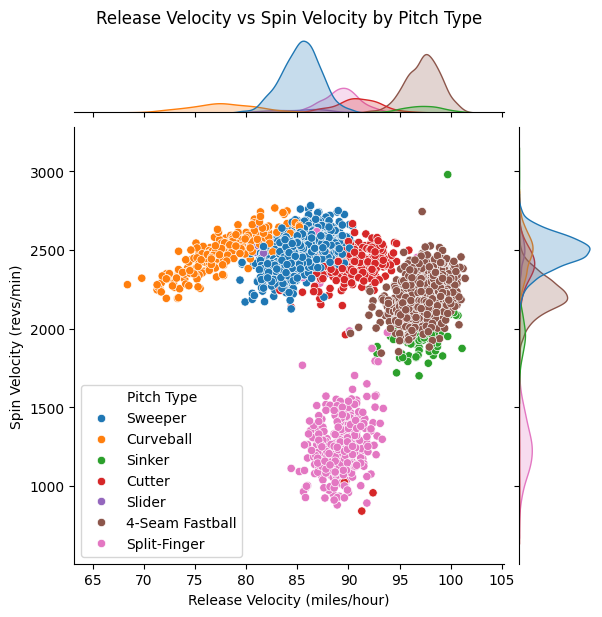

In [133]:
# visualization
h = sns.jointplot(pitches_train, x='release_speed', y='release_spin_rate', hue='pitch_name')
h.set_axis_labels(xlabel="Release Velocity (miles/hour)", ylabel="Spin Velocity (revs/min)")
plt.legend(title='Pitch Type', loc='lower left')
h.ax_joint.set_title('Release Velocity vs Spin Velocity by Pitch Type', pad=75)
plt.show(h)

Visualizing the relationship between release velocity (x-axis) and spin velocity (y-axis) for different types of baseball pitches, we see that the data is clustered and fairly well-separated for most pitch types. This indicates that the data may be modeled well with a KNN classifier. 

For example, the 4-seam fastballs (brown) form a distinct cluster with high release velocities and moderate spin velocities, while curveballs (orange) are grouped at lower release velocities with slightly higher spin velocities. However, there is some overlap between pitches like cutters (red) and sweepers (blue), which might cause confusion for the model. Similarly, pitches like the sinkers (green) and sliders (purple) who have significantly less observations may result in model classifying them incorrectly as one of the more frequent types simply because they have fewer representative neighbors.

There is also some missing data, which we should plan to handle when finding our model.

### Models

In [134]:
# process data for ML
# create X and y for train
X_train = pitches_train.drop("pitch_name", axis=1)
y_train = pitches_train["pitch_name"]

# create X and y for test
X_test = pitches_test.drop("pitch_name", axis=1)
y_test = pitches_test["pitch_name"]

In [135]:
X_train

,release_speed,release_spin_rate,pfx_x,pfx_z,stand
0,84.7,2667.0,1.25,0.01,R
1,83.9,2634.0,1.41,0.20,R
2,84.4,2526.0,1.26,0.25,R
3,74.3,2389.0,0.93,-1.10,L
4,85.6,2474.0,1.08,0.52,R
...,...,...,...,...,...
2623,91.8,1314.0,-0.30,0.08,R
2624,86.9,2440.0,1.11,0.51,R
2625,99.2,2320.0,0.04,0.81,R
2626,97.9,2164.0,0.08,1.06,R


In [136]:
# train models
# note numeric and categorical features
numeric_features = ["release_speed", "release_spin_rate", "pfx_x", "pfx_z"]
categorical_features = ["stand"]

# define preprocessing for numeric features
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

# define preprocessing for categorical features
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder()),
    ]
)

# combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# create pipeline, preprocess then classify
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier()),
    ]
)


In [137]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['release_speed',
                                                   'release_spin_rate', 'pfx_x',
                                                   'pfx_z']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder())]),
                                                  ['stand'])])),
                ('classifier', KNeighborsClassifier())])

In [138]:
# define parameter grid
param_grid = {
    "preprocessor__cat__onehot__drop": [None, "first"],
    "preprocessor__num__scaler": [None, StandardScaler()],
    "classifier__n_neighbors": [3, 5, 7, 9, 11],
    "classifier__metric": ["euclidean", "manhattan"],
}

In [139]:
# setup grid search with cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy")

In [140]:
# run grid search with cross-validation
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['release_speed',
                                                                          'release_spin_rate',
                                                                          'pfx_x',
                                                                          'pfx_z']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder())]),
                                                                         ['stand'])])),
                                       ('classifier', KNeighborsClassifier())]),
             param_grid={'classifier__metric': ['euclidean', 'manhattan'],
                         'classifier__n_neighbors': [3, 5, 7, 9, 11],
                         'preprocessor__cat__onehot__drop': [None, 'first'],
                         'preprocessor__num__scaler': [None, StandardScaler()]},
             scoring='accuracy')

In [141]:
# print best parameters found and best (cross-validated) score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_}")

Best parameters: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 9, 'preprocessor__cat__onehot__drop': None, 'preprocessor__num__scaler': StandardScaler()}
Best cross-validation accuracy: 0.9760195545898969


Here we used a tuning pipeline to try and find the best cross-validated KNN classifier model.

## Results

In [142]:
# final evaluation on test set
y_pred = grid_search.predict(X_test)
print(f"Test set accuracy: {accuracy_score(y_test, y_pred)}")

Test set accuracy: 0.9358024691358025


The selected model achieves a test accuracy of 0.935.

## Discussion

Given that the model achieved a strong final test accuracy of 0.935, this model appears to be a good predictor of pitch type. However, this is a drop from the cross-validated accuracy of 0.976. The drop could be due to variability in the 2023 test data, Shohei Ohtani could have altered his pitching techniques in the off-season resulting in new trends in pitch and spin velocity for example. Pitchers can even learn new pitches. This presents one potential issue with predicting future performance because of how these trends can change over time.

We can expect such variations to occur across every pitcher in Major League Baseball (MLB), so expanding the model to be generalized for all MLB pitchers would require us to accommodate each pitcher’s unique tendencies, likely resulting in even greater variability. The dataset for such a system would need to include observations from a diverse array of pitchers across all pitch types to make sure that the model can predict pitch types even for those who have yet to throw their first MLB pitch. 

Running a model in real time with that many observations to train on may not be fast enough to be an effective classifier. Some modifications may need to be made in either the model type of scale for such a generalized model to work. But for the original model tailored to the singular pitcher, I believe the dataset size is small enough for it to be applicable in real-time.

### Conclusion

Given the high performance accuracy and adequate speed, I recommend this model for use in practice.

In [143]:
from joblib import dump
dump(grid_search, "pitch-classifier.joblib")

['pitch-classifier.joblib']